# AusGrid PV AS/NZS 4777.2 Conformance

## Aggregation rule
| quantity | how combined across phases | why |
|---|---|---|
| **voltage** (drives the response) | **mean** (`V_avg`) | intensive *level*; balanced-output unit responds to the level, not a sum |
| **active power** P | **sum** (`P_total`) | extensive throughput; unit total = ΣP_i |
| **reactive power** Q | **sum** (`Q_total`) | extensive throughput; unit total = ΣQ_i |
| **apparent power** S | `√(P_total²+Q_total²)` | from the *summed* P,Q (≡ ΣS_i only when balanced) |
| voltage spread (diagnostic) | `max-min` (`V_spread`) | flags imbalance / which phase runs hot |


> ASSUMPTION (validated empirically in §4b): the unit responds to **average** phase voltage.
> §4b checks, per site, whether aggregate Q tracks `V_avg` better than `V_max`. If a site
> tracks `V_max`, its inverter uses a different reference and its Tier-2 result is flagged.

## Reference quantity for the curves (confirmed)
Volt-Watt is a **ceiling = % of the inverter's rated power, evaluated at the present
voltage** (100 % ≤253 V → 20 % ≥260 V). In the 253–258 V overlap both modes run concurrently
and reactive demand may pull active power below the Volt-Watt ceiling (apparent-power
priority).

## 1. Setup, constants & thresholds

In [13]:
from pathlib import Path
import warnings, gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
try:
    from tqdm.auto import tqdm
    tqdm.pandas()
    HAVE_TQDM = True
except Exception:
    HAVE_TQDM = False
    print("tqdm not installed -> no progress bars. `pip install tqdm` to enable.")

warnings.simplefilter("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 60); pd.set_option("display.width", 170)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

In [14]:
# AS/NZS 4777.2:2020 Australia A default set-points (Tables 3.6 / 3.7)
AS4777 = {
    "Vnom": 230.0,
    # Volt-Watt (Table 3.6): P cap is % of S_rated
    "VW1": 253.0,   # 100% S_rated
    "VW2": 260.0,   #  20% S_rated
    # Volt-VAr (Table 3.7): Q level is % of S_rated
    "VV1": 207.0,   # 44% supplying
    "VV2": 220.0,   #  0%
    "VV3": 240.0,   #  0%   (220-240 = 0% deadband)
    "VV4": 258.0,   # 60% absorbing
    "VW_minP_pct": 20.0,
    "VV_supply_pct": 44.0,
    "VV_absorb_pct": 60.0,
}

# Tier-1 (scale-free, direction) thresholds
MIN_ZONE_SAMPLES   = 200    # min in-zone (site,timestamp) rows before a curve is "testable"
CORR_RESPONSIVE    = 0.20   # |corr(V_avg, absorption)| above this = responsive
DEADBAND_CLEAN_MAX = 0.30   # deadband |Q| / absorb |Q| below this = clean deadband

# Tier-2 (magnitude, needs nameplate) tolerances
# Expressed as a FRACTION of the (inferred) rating, plus an absolute floor in VA/W,
# to avoid punishing tiny systems on rounding. These are pragmatic, NOT from the standard's
# test tolerances (those assume bench testing); state this in any write-up.
Q_TOL_FRAC = 0.10    # |Q residual| within 10% of inferred S_rated = magnitude-conforming
Q_TOL_FLOOR_VAR = 100.0
P_TOL_FRAC = 0.10    # active power may exceed the V-W ceiling by up to 10% before "violation"
P_TOL_FLOOR_W = 100.0
# Capacity inference
CAP_QUANTILE = 0.995   # high percentile of total power used as the rating proxy
CAP_PLATEAU_MIN = 0.01 # >=1% of samples must sit just under the cap (evidence of real clipping)
# Sign convention: None = auto-infer from fleet (§5). Set -1/+1 once provider confirms.
FLEET_SIGN_OVERRIDE = None

## 2. Memory-lean load, column registry, zone & expected-curve helpers
Loads only needed columns, casts strings=>`category` and floats=>`float32`, and never
materialises object-dtype zone labels on the full frame (that alone added ~30 GB in v1).
If `df` already exists from a loader notebook it is reused and down-cast in place.

In [15]:
PARQUET_IN = Path(r"C:\Users\z3553082\OneDrive - UNSW\Documents\CICCADA - Data\AUSGrid\ausgrid_pv_combined.parquet")

USE_COLS = ["serial","MeasureTime","Vphase","Volts","Curr","ReactPow","ActivePow"]
CAT_COLS = ["serial","Vphase"]
FLT_COLS = ["Volts","Curr","ReactPow","ActivePow"]

def shrink(d):
    for c in CAT_COLS:
        if c in d and str(d[c].dtype) != "category": d[c] = d[c].astype("category")
    for c in FLT_COLS:
        if c in d and d[c].dtype != "float32": d[c] = d[c].astype("float32")
    return d

try:
    df = shrink(df)                       # noqa: F821  reuse + downcast in place
    print("Reusing in-memory `df` (down-cast).")
except NameError:
    df = pd.read_parquet(PARQUET_IN, engine="pyarrow",
                         columns=[c for c in USE_COLS])
    df = shrink(df)
    print(f"Loaded {PARQUET_IN.name}")
if not pd.api.types.is_datetime64_any_dtype(df["MeasureTime"]):
    df["MeasureTime"] = pd.to_datetime(df["MeasureTime"], utc=True, errors="coerce")
print(f"{len(df):,} rows | mem={df.memory_usage(deep=True).sum()/1e9:.2f} GB")
gc.collect()

Reusing in-memory `df` (down-cast).
303,647,633 rows | mem=8.20 GB


0

In [16]:
SITE_COL, TIME_COL, PHASE_COL = "serial", "MeasureTime", "Vphase"

def first_present(*names):
    low = {c.lower(): c for c in df.columns}
    for n in names:
        if n.lower() in low: return low[n.lower()]
    return None

ROLES = {"voltage":first_present("Volts","voltage","v"),
         "current":first_present("Curr","current","i"),
         "active_power":first_present("ActivePow","active_power","p"),
         "reactive_power":first_present("ReactPow","reactive_power","q"),
         "nameplate":first_present("s_rated","rating","nameplate","capacity_va")}

present = {k:v for k,v in ROLES.items() if v}
vcol, qcol, pcol = present.get("voltage"), present.get("reactive_power"), present.get("active_power")
print("PRESENT:", present)
print("[Tier-2] nameplate provided." if present.get("nameplate")
      else "[Tier-2] no nameplate -> will INFER it in §6.")

PRESENT: {'voltage': 'Volts', 'current': 'Curr', 'active_power': 'ActivePow', 'reactive_power': 'ReactPow'}
[Tier-2] no nameplate -> will INFER it in §6 (indicative only).


In [20]:
# Expected response curves -> FRACTION of rated power
def expected_vvar_q_fraction(v):
    # + supplying (low V) ... - absorbing (high V). Table 3.7
    return np.interp(np.asarray(v,float),
        [AS4777["VV1"],AS4777["VV2"],AS4777["VV3"],AS4777["VV4"]],
        [ AS4777["VV_supply_pct"]/100, 0.0, 0.0, -AS4777["VV_absorb_pct"]/100],
        left=AS4777["VV_supply_pct"]/100, right=-AS4777["VV_absorb_pct"]/100)
def expected_vw_p_cap_fraction(v):
    # active-power CEILING as % rated. Table 3.6
    return np.interp(np.asarray(v,float),
        [AS4777["VW1"],AS4777["VW2"]],[1.0,AS4777["VW_minP_pct"]/100],
        left=1.0, right=AS4777["VW_minP_pct"]/100)
def vvar_zone_code(v):
    # int8 codes (NOT object strings) to keep memory low.
    return np.select([v<AS4777["VV1"],v<AS4777["VV2"],v<AS4777["VV3"],v<AS4777["VV4"]],
                     [0,1,2,3], default=4).astype("int8")
print("curve check:", {V:(round(float(expected_vvar_q_fraction(V)),2),
                            round(float(expected_vw_p_cap_fraction(V)),2))
                       for V in (207,230,253,258,260)})

curve check: {207: (0.44, 1.0), 230: (0.0, 1.0), 253: (-0.43, 1.0), 258: (-0.6, 0.43), 260: (-0.6, 0.2)}


## 3. Connection topology per site (1-phase vs 3-phase)
Observed topology, inferred per (site,timestamp) then reduced to the modal phase count, so a brief comms dropout doesn't mislabel a 3-phase site. `consistency` < 0.95

In [21]:
pps = df.groupby([SITE_COL, TIME_COL], observed=True)[PHASE_COL].nunique()
topology = pd.DataFrame({
    "n_phases":    pps.groupby(level=0).agg(lambda s: s.mode().iloc[0]),
    "consistency": pps.groupby(level=0).agg(lambda s: (s==s.mode().iloc[0]).mean()),
    "phase_set":   df.groupby(SITE_COL, observed=True)[PHASE_COL]
                     .agg(lambda s: "".join(sorted(s.dropna().astype(str).unique()))),
})
topology["topology"] = topology["n_phases"].map(
    {1:"single-phase",2:"split/2-phase",3:"three-phase"}).fillna("other")
print(topology["topology"].value_counts())
print("\nmixed-topology sites (consistency<0.95):")
display(topology[topology["consistency"]<0.95].head(15))
del pps; gc.collect()

topology
three-phase      653
single-phase     613
split/2-phase     76
Name: count, dtype: int64

mixed-topology sites (consistency<0.95):


,n_phases,consistency,phase_set,topology
serial,,,,


0

## 4. Aggregate phases to the UNIT grain  (avg voltage, summed power)
Collapsing the 3 per-phase rows at each (site,timestamp) into one unit-level record:
- `V_avg` = **mean** phase voltage  → the control input the inverter responds to. See AS4777.2.2020 section 3.3.2.1.
- `P_total`,`Q_total` = **sum** of phase power, the unit's actual throughput
- `S_total` = √(P_total²+Q_total²) → unit apparent power (VA)
- `V_spread` = max−min phase voltage → imbalance diagnostic (kept, not used for conformance)

Single-phase sites pass through unchanged (mean/sum of one value = that value).

In [22]:
# vectorised aggregation 300M phase-rows -> ~100M unit-rows
g = df.groupby([SITE_COL, TIME_COL], observed=True)
unit = g.agg(
    V_avg   =(vcol,"mean"),
    V_max   =(vcol,"max"),
    V_min   =(vcol,"min"),
    P_total =(pcol,"sum"),
    Q_total =(qcol,"sum"),
    n_phase =(PHASE_COL,"nunique"),
).reset_index()
for c in ["V_avg","V_max","V_min","P_total","Q_total"]:
    unit[c] = unit[c].astype("float32")
unit["V_spread"] = (unit["V_max"] - unit["V_min"]).astype("float32")
unit["S_total"]  = np.hypot(unit["P_total"], unit["Q_total"]).astype("float32")
unit["vvar_zone"] = vvar_zone_code(unit["V_avg"].values)   # int8, cheap
print(f"unit-grain rows: {len(unit):,} | mem={unit.memory_usage(deep=True).sum()/1e9:.2f} GB")
print(unit[["V_avg","V_spread","P_total","Q_total","S_total"]].describe().round(1))
# Optional: free the 300M-row frame if memory is tight (per-phase §9 re-reads if needed)
# del df; gc.collect()

unit-grain rows: 140,069,836 | mem=6.58 GB
                 V_avg         V_spread          P_total          Q_total          S_total
count 140,069,836.0000 140,069,836.0000 140,069,836.0000 140,069,836.0000 140,069,836.0000
mean          241.2000           4.1000        -134.8000         -32.7000       1,083.2000
std            13.0000          25.8000      51,697.9000      10,363.0000      52,715.4000
min             0.0000           0.0000 -80,457,920.0000  -7,249,381.0000           0.0000
25%           240.3000           0.0000           0.0000        -347.2000           0.0000
50%           242.8000           0.0000           0.0000           0.0000         305.5000
75%           244.9000           1.9000         219.5000           0.0000       1,080.2000
max           266.3000         256.1000  99,193,992.0000  27,874,382.0000  99,325,280.0000


In [70]:
ranking_df = (
    unit.groupby("serial")
    .filter(lambda df: not ((df["P_total"] == 0).all() and (df["Q_total"] == 0).all()))
    .groupby("serial")["V_avg"]
    .max()
    .reset_index()
    .sort_values(by="V_avg", ascending=False)
)

ranking_df["rank"] = ranking_df["V_avg"].rank(method="dense", ascending=False)

In [71]:
ranking_df

,serial,V_avg,rank
126,810508901,258.0465,1.0000
477,810903595,257.1962,2.0000
33,810201618,256.9849,3.0000
485,810931071,256.6345,4.0000
484,810928069,256.3768,5.0000
...,...,...,...
64,810233177,163.9540,653.0000
719,811288078,163.2463,654.0000
487,810960470,162.9165,655.0000
630,811113354,161.6797,656.0000


In [81]:
import numpy as np
import plotly.graph_objects as go

# Filter your site
site = unit.loc[
    unit["serial"] == 810928069,
    ["MeasureTime", "V_avg", "Q_total", "P_total"]
].copy()

# Ensure sorted time (important for plotting)
site = site.sort_values("MeasureTime")

# 1. Calculate kVA
site["kVA"] = np.sqrt(site["P_total"]**2 + site["Q_total"]**2)

# 2. Normalize both variables (so they overlap visually)
site["kVA_norm"] = (
    (site["kVA"] - site["kVA"].min()) /
    (site["kVA"].max() - site["kVA"].min())
)

site["V_norm"] = (
    (site["V_avg"] - site["V_avg"].min()) /
    (site["V_avg"].max() - site["V_avg"].min())
)

# 3. Flag high voltage points
site["V_flag"] = site["V_avg"] > 253
flagged = site[site["V_flag"]]

# Create figure
fig = go.Figure()

# Plot normalized kVA
fig.add_trace(go.Scatter(
    x=site["MeasureTime"],
    y=site["kVA_norm"],
    name="kVA (normalized)",
    line=dict(color="blue", width=2)
))

# Plot normalized voltage
fig.add_trace(go.Scatter(
    x=site["MeasureTime"],
    y=site["V_norm"],
    name="V_avg (normalized)",
    line=dict(color="orange", width=2)
))

# Highlight where voltage exceeds limit
fig.add_trace(go.Scatter(
    x=flagged["MeasureTime"],
    y=flagged["V_norm"],
    mode="markers",
    name="V_avg > 253",
    marker=dict(color="red", size=8)
))

# Optional: horizontal reference (e.g., normalized threshold ~253 V)
v_threshold_norm = (
    (253 - site["V_avg"].min()) /
    (site["V_avg"].max() - site["V_avg"].min())
)

fig.add_hline(
    y=v_threshold_norm,
    line=dict(color="red", dash="dash"),
    annotation_text="253 V threshold (normalized)",
    annotation_position="top right"
)

# Layout
fig.update_layout(
    title="Voltage vs Generation (Overlaid - Normalized)",
    xaxis_title="MeasureTime",
    yaxis_title="Normalized scale (0–1)",
    legend=dict(x=0.01, y=0.99)
)

fig.show()

### 4b. Empirical check: does the unit respond to `V_avg` or to `V_max`?
Validates the averaging assumption per site. We correlate aggregate absorption with `V_avg`
vs `V_max` in the absorb zone; whichever is stronger is the inverter's effective reference.
Sites that clearly prefer `V_max` are flagged so their Tier-2 magnitude result is read with
care (the expected curve there should arguably use `V_max`, not `V_avg`).

In [23]:
# defer until after sign convention so 'absorption' exists; placeholder computed in §5.
print("V_avg-vs-V_max reference check is produced at the end of §5 (needs 'absorption').")

V_avg-vs-V_max reference check is produced at the end of §5 (needs 'absorption').


## 5. Resolve the fleet reactive-power sign convention (on unit `Q_total`)
Convention is global metering metadata. If the fleet is mostly conforming, the absorb zone
(`V_avg`≥240) is dominated by genuine absorbing. We read its dominant sign and define
`absorption = Q_total × FLEET_SIGN` so **positive = absorbing** regardless of raw convention.
Provider confirmation later → set `FLEET_SIGN_OVERRIDE`, all labels flip consistently.

In [94]:
absorb_q = unit.loc[unit["V_avg"] >= AS4777["VV3"], "Q_total"]
absorb_fracneg = float((absorb_q < 0).mean()) if len(absorb_q) else np.nan

if FLEET_SIGN_OVERRIDE is not None:
    FLEET_SIGN, src = float(FLEET_SIGN_OVERRIDE), "OVERRIDE (provider confirmed)"
else:
    # We do NOT infer from fleet behaviour, because conformance is what we are testing.
    # FLEET_SIGN = +1 means absorption = Q_total unchanged (provisional; no flip applied).
    # Set FLEET_SIGN_OVERRIDE = -1.0 if provider confirms negative = absorbing.
    FLEET_SIGN, src = 1.0, "provisional (no flip — awaiting provider confirmation)"

unit["absorption"] = (unit["Q_total"] * FLEET_SIGN).astype("float32")

print(f"absorb zone n={len(absorb_q):,}")
print(f"  Q > 0: {1-absorb_fracneg:.2f}   Q < 0: {absorb_fracneg:.2f}   Q≈0 (|Q|<50): "
      f"{(absorb_q.abs()<50).mean():.2f}")
print(f"FLEET_SIGN = {FLEET_SIGN:+.0f}  ({src})")
print("ACTION REQUIRED: confirm whether negative ReactPow = absorbing.")
print("When confirmed: set FLEET_SIGN_OVERRIDE at top of notebook and re-run.")

absorb zone n=107,956,222
  Q > 0: 0.66   Q < 0: 0.34   Q≈0 (|Q|<50): 0.50
FLEET_SIGN = +1  (provisional (no flip — awaiting provider confirmation))
ACTION REQUIRED: confirm whether negative ReactPow = absorbing.
When confirmed: set FLEET_SIGN_OVERRIDE at top of notebook and re-run.


In [25]:
# §4b reference check (now that 'absorption' exists)
def ref_pref(g):
    m = g["V_avg"]>=AS4777["VV3"]
    # every branch must return the SAME keys, else groupby.apply yields a
    # MultiIndexed Series and ref_check["ref"] raises KeyError.
    if m.sum()<30 or g.loc[m,"V_avg"].nunique()<3:
        return pd.Series({"corr_Vavg":np.nan,"corr_Vmax":np.nan,"ref":"untestable"})
    c_avg = g.loc[m,"V_avg"].corr(g.loc[m,"absorption"])
    c_max = g.loc[m,"V_max"].corr(g.loc[m,"absorption"])
    return pd.Series({"corr_Vavg":c_avg,"corr_Vmax":c_max,
                      "ref":("V_max" if (abs(c_max)-abs(c_avg))>0.05 else "V_avg")})
_it = unit.groupby(SITE_COL, observed=True)
ref_check = (_it.progress_apply(ref_pref, include_groups=False) if HAVE_TQDM
             else _it.apply(ref_pref, include_groups=False))
print(ref_check["ref"].value_counts())

  0%|          | 1/1342 [00:01<30:54,  1.38s/it]c:\Users\z3553082\AppData\Local\miniforge3\envs\ciccada\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\z3553082\AppData\Local\miniforge3\envs\ciccada\Lib\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
100%|██████████| 1342/1342 [00:08<00:00, 160.02it/s]

ref
V_avg         1079
V_max          239
untestable      24
Name: count, dtype: int64


## 6. Infer system size (nameplate). Tier-2 enabler
### ⚠ ASSUMPTIONS & BIASES
We have **no provider nameplate**, so we estimate each site's rating from its own peak
output. This is defensible for *segmentation and indicative* magnitude checks, **not** for
definitive compliance claims.
1. **Export limits / DOE / EBM** cap observed power below nameplate → we infer the *limit*,
   not the inverter. CICCADA studies these limits, so this is the dominant risk.
2. **Volt-Watt curtailment itself** depresses the peak → circular: curtailment biases the
   size estimate down, which then hides curtailment. Worst at high-voltage sites.
3. **Oversized inverter / undersized array** → never reaches the AC limit → underestimate.
4. **Net-of-load metering** (if `ActivePow` were net, not inverter-terminal) → underestimate.
5. **Short / winter-only window** → seasonal underestimate.

MITIGATIONS encoded below: (a) use a high percentile (`CAP_QUANTILE`) of **total active
power** as the active-rating proxy and of **total apparent power** for the VA rating;
(b) a **plateau test** — real inverter clipping shows mass piled just under the cap; if that
mass is < `CAP_PLATEAU_MIN`, the estimate is unreliable and `cap_reliable=False`; (c) we
keep the estimate per-site and **never** let an unreliable one drive a published number.
Treat every Tier-2 result as *indicative*, gate hard conclusions on a real nameplate.

In [26]:
def infer_capacity(g):
    P, S = g["P_total"].astype("float32"), g["S_total"].astype("float32")
    cap_P = float(P.quantile(CAP_QUANTILE))
    cap_S = float(S.quantile(CAP_QUANTILE))
    plateau = float(((P>=0.97*cap_P)&(P<=cap_P)).mean()) if cap_P>0 else 0.0
    return pd.Series({"cap_P_W":cap_P, "cap_S_VA":cap_S, "plateau_frac":plateau,
                      "cap_reliable": plateau>=CAP_PLATEAU_MIN})
_it = unit.groupby(SITE_COL, observed=True)
capacity = (_it.progress_apply(infer_capacity, include_groups=False) if HAVE_TQDM
            else _it.apply(infer_capacity, include_groups=False))
print(f"reliable capacity estimates: {int(capacity['cap_reliable'].sum())}/{len(capacity)}")
display(capacity.head(10))
# join the inferred VA rating onto every unit row for Tier-2
unit = unit.merge(capacity[["cap_S_VA","cap_P_W","cap_reliable"]],
                  left_on=SITE_COL, right_index=True, how="left")

100%|██████████| 1342/1342 [00:03<00:00, 377.86it/s]

reliable capacity estimates: 12/1342


,cap_P_W,cap_S_VA,plateau_frac,cap_reliable
serial,,,,
326214487,"2,424.9690","4,800.4452",0.0010,False
326214520,"6,054.7646","6,310.0157",0.0008,False
326228801,0.0000,0.0000,0.0000,False
326612333,0.0000,0.0000,0.0000,False
361431370,0.0000,0.0000,0.0000,False
810014969,"8,087.2719","8,092.8876",0.0010,False
810014979,"8,372.5244","9,283.6694",0.0020,False
810015442,"5,784.1890","6,394.9924",0.0007,False
810017544,"5,618.4233","9,636.2231",0.0007,False


## 7. Tier-1. Direction conformance (scale-free, trustworthy)  per SITE
Same logic as v1 but on the **unit** grain (`V_avg`, `absorption`). Behaviour class from:
responsiveness (corr V_avg↔absorption), correct direction (absorbs more as V rises), and the
**deadband-cleanliness ratio**.

In [86]:
def tier1_vvar(g):
    v, a = g["V_avg"].values, g["absorption"].values
    in_ab = v>=AS4777["VV3"]; in_dl=(v>=AS4777["VV2"])&(v<AS4777["VV3"])
    out={"n_absorb":int(in_ab.sum()),"n_dead":int(in_dl.sum())}
    out["corr_V_absorption"]=(np.corrcoef(v[in_ab],a[in_ab])[0,1]
                              if in_ab.sum()>=30 and np.ptp(v[in_ab])>1 else np.nan)
    ab_med=np.nanmedian(np.abs(a[in_ab])) if in_ab.sum() else np.nan
    dl_med=np.nanmedian(np.abs(a[in_dl])) if in_dl.sum() else np.nan
    out["deadband_ratio"]=(dl_med/ab_med if ab_med and ab_med>1e-9 else np.nan)
    return pd.Series(out)
_it = unit.groupby(SITE_COL, observed=True)
t1 = (_it.progress_apply(tier1_vvar, include_groups=False) if HAVE_TQDM
      else _it.apply(tier1_vvar, include_groups=False))
testable=t1["n_absorb"]>=MIN_ZONE_SAMPLES
responsive=t1["corr_V_absorption"].abs()>=CORR_RESPONSIVE
correct=t1["corr_V_absorption"]>0
clean=t1["deadband_ratio"].isna()|(t1["deadband_ratio"]<=DEADBAND_CLEAN_MAX)
t1["vvar_behaviour"]=np.select(
    [~testable, responsive&correct&clean, responsive&correct&~clean, responsive&~correct],
    ["untestable","true_vvar","fixed_pf_like","inverted"], default="unresponsive")
t1["tier1_conforms"]=t1["vvar_behaviour"]=="true_vvar"
print(t1["vvar_behaviour"].value_counts())

  0%|          | 1/1342 [00:01<36:23,  1.63s/it]c:\Users\z3553082\AppData\Local\miniforge3\envs\ciccada\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\z3553082\AppData\Local\miniforge3\envs\ciccada\Lib\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
100%|██████████| 1342/1342 [00:04<00:00, 292.47it/s]

vvar_behaviour
unresponsive     956
fixed_pf_like    300
inverted          45
untestable        30
true_vvar         11
Name: count, dtype: int64


## 8. Tier-2. Magnitude conformance (uses INFERRED nameplate — indicative)
For each unit row we compute the expected response from the curve × the site's inferred
rating, then compare to observed:
- **Volt-VAr (target):** expected absorbing VA = −`expected_vvar_q_fraction(V_avg)` × `cap_S_VA`
  (negative fraction = absorbing → positive absorption). Residual = observed − expected.
  Conforms if |residual| ≤ max(`Q_TOL_FRAC`·cap, floor).
- **Volt-Watt (ceiling):** expected cap W = `expected_vw_p_cap_fraction(V_avg)` × `cap_P_W`.
  Only *exceeding* the ceiling is a violation (being under it is fine). Overshoot =
  max(0, P_total − cap). Conforms if overshoot ≤ max(`P_TOL_FRAC`·cap, floor).

Every result carries `cap_reliable`; aggregate Tier-2 stats in §10 are reported **only over
reliable-capacity sites**, and even then are *indicative* pending a real nameplate.

In [28]:
u = unit  # alias
# Volt-VAr magnitude (work in 'absorption' space; expected absorbing is positive)
exp_absorb_frac = -expected_vvar_q_fraction(u["V_avg"].values)      # + = absorbing
u["q_expected"]  = (exp_absorb_frac * u["cap_S_VA"].values).astype("float32")
u["q_residual"]  = (u["absorption"] - u["q_expected"]).astype("float32")
q_tol = np.maximum(Q_TOL_FRAC*u["cap_S_VA"].values, Q_TOL_FLOOR_VAR)
u["vvar_mag_conforms"] = (np.abs(u["q_residual"].values) <= q_tol)

# Volt-Watt magnitude (ceiling)
u["p_cap"]      = (expected_vw_p_cap_fraction(u["V_avg"].values)*u["cap_P_W"].values).astype("float32")
u["p_overshoot"]= np.clip(u["P_total"].values - u["p_cap"].values, 0, None).astype("float32")
p_tol = np.maximum(P_TOL_FRAC*u["cap_P_W"].values, P_TOL_FLOOR_W)
u["vw_mag_conforms"] = (u["p_overshoot"].values <= p_tol)

# per-site Tier-2 rates, in the relevant zones only
def tier2_site(g):
    ab = g["V_avg"]>=AS4777["VV3"]; vw = g["V_avg"]>=AS4777["VW1"]
    return pd.Series({
        "n_absorb":int(ab.sum()), "n_vw":int(vw.sum()),
        "vvar_mag_rate": g.loc[ab,"vvar_mag_conforms"].mean() if ab.sum() else np.nan,
        "vw_mag_rate":   g.loc[vw,"vw_mag_conforms"].mean()   if vw.sum() else np.nan,
        "cap_reliable":  bool(g["cap_reliable"].iloc[0]),
    })
_it = unit.groupby(SITE_COL, observed=True)
t2 = (_it.progress_apply(tier2_site, include_groups=False) if HAVE_TQDM
      else _it.apply(tier2_site, include_groups=False))
print("Tier-2 V-VAr magnitude rate (reliable-capacity sites only):")
print(t2.loc[t2["cap_reliable"],"vvar_mag_rate"].describe().round(3))

100%|██████████| 1342/1342 [00:03<00:00, 382.77it/s]

Tier-2 V-VAr magnitude rate (reliable-capacity sites only):
count   11.0000
mean     0.6080
std      0.3410
min      0.0050
25%      0.3480
50%      0.7200
75%      0.8530
max      0.9960
Name: vvar_mag_rate, dtype: float64


## 9. Per-phase diagnostics (secondary): imbalance + direction cross-check
Not the conformance unit, but valuable: (a) voltage **imbalance** per site (from `V_spread`),
which is both a finding and a data-quality flag; (b) a per-(site,phase) **direction** check —
if the unit looks conforming but one phase disagrees, that's worth seeing. This preserves the
per-(site,phase) long-tail artefact.

In [ ]:
imb = unit.groupby(SITE_COL, observed=True).agg(
    v_spread_med=("V_spread","median"), v_spread_p95=("V_spread", lambda s: s.quantile(0.95)),
    n_imbalanced=("V_spread", lambda s: int((s>10).sum())))   # >10 V spread as a rough flag
print("voltage imbalance per site (head):"); display(imb.head(10))

# per-phase direction cross-check (reuses raw per-phase df; skip if df was deleted)
if "df" in dir():
    dfp = df.copy()
    dfp["absorption_ph"] = dfp[qcol]*FLEET_SIGN
    def ph_dir(g):
        m=g[vcol]>=AS4777["VV3"]    
        if m.sum()<30 or np.ptp(g.loc[m,vcol])<1: return np.nan
        return g.loc[m,vcol].corr(g.loc[m,"absorption_ph"])
    _it = dfp.groupby([SITE_COL,PHASE_COL], observed=True)
    ph = (_it.progress_apply(ph_dir, include_groups=False) if HAVE_TQDM
          else _it.apply(ph_dir, include_groups=False)).rename("corr_V_absorption_phase")
    print("\nper-phase direction correlation (head):"); display(ph.head(12))
    del dfp; gc.collect()
else:
    print("(raw per-phase df was freed; skip per-phase cross-check)")

voltage imbalance per site (head):


,v_spread_med,v_spread_p95,n_imbalanced
serial,,,
326214487,2.5251,5.6377,153
326214520,3.2260,5.5862,33
326228801,0.0000,0.0000,0
326612333,0.0000,0.0000,0
361431370,0.0000,0.0000,0
810014969,1.9067,4.6277,6
810014979,1.9789,5.1636,44
810015442,2.1335,5.6068,134
810017544,0.0000,0.0103,0


  0%|          | 3/2724 [00:35<7:03:09,  9.33s/it] c:\Users\z3553082\AppData\Local\miniforge3\envs\ciccada\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\z3553082\AppData\Local\miniforge3\envs\ciccada\Lib\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
100%|██████████| 2724/2724 [00:49<00:00, 54.82it/s] 


per-phase direction correlation (head):


serial     Vphase
326214487  A         0.0593
           B        -0.0939
           C         0.6340
326214520  A         0.6859
           B        -0.0860
           C        -0.0345
326228801  A            NaN
326612333  A            NaN
361431370  A            NaN
810014969  A        -0.1276
           B        -0.0994
           C        -0.0742
Name: corr_V_absorption_phase, dtype: float64

## 10. Assemble master tables + export (all reporting views)
- **by_site** — Tier-1 behaviour + Tier-2 indicative rates + topology + capacity + imbalance.
- **site_phase** — per-phase direction cross-check (the long-tail diagnostic artefact).

In [30]:
by_site = (topology.join(capacity).join(t1).join(t2[["vvar_mag_rate","vw_mag_rate","n_absorb"]],
            rsuffix="_t2").join(imb))
by_site.to_csv("ausgrid_conformance_v2_by_site.csv")
print(f"wrote ausgrid_conformance_v2_by_site.csv  ({len(by_site)} sites)")
print("\nTier-1 behaviour x topology:")
print(by_site.groupby("topology")["vvar_behaviour"].value_counts())
display(by_site.head(8))

wrote ausgrid_conformance_v2_by_site.csv  (1342 sites)

Tier-1 behaviour x topology:
topology       vvar_behaviour
single-phase   unresponsive      612
               untestable          1
split/2-phase  fixed_pf_like      49
               unresponsive       22
               inverted            2
               untestable          2
               true_vvar           1
three-phase    unresponsive      322
               fixed_pf_like     251
               inverted           43
               untestable         27
               true_vvar          10
Name: count, dtype: int64


,n_phases,consistency,phase_set,topology,cap_P_W,cap_S_VA,plateau_frac,cap_reliable,n_absorb,n_dead,corr_V_absorption,deadband_ratio,vvar_behaviour,tier1_conforms,vvar_mag_rate,vw_mag_rate,n_absorb_t2,v_spread_med,v_spread_p95,n_imbalanced
serial,,,,,,,,,,,,,,,,,,,,
326214487,3,1.0000,ABC,three-phase,"2,424.9690","4,800.4452",0.0010,False,"102,101.0000","2,947.0000",0.1379,1.0290,unresponsive,False,0.4631,NaN,102101,2.5251,5.6377,153
326214520,3,1.0000,ABC,three-phase,"6,054.7646","6,310.0157",0.0008,False,"39,877.0000","65,113.0000",0.3012,1.0451,fixed_pf_like,False,0.3416,NaN,39877,3.2260,5.5862,33
326228801,1,1.0000,A,single-phase,0.0000,0.0000,0.0000,False,"68,317.0000","36,627.0000",NaN,NaN,unresponsive,False,1.0000,1.0000,68317,0.0000,0.0000,0
326612333,1,1.0000,A,single-phase,0.0000,0.0000,0.0000,False,"39,950.0000","64,827.0000",NaN,NaN,unresponsive,False,1.0000,NaN,39950,0.0000,0.0000,0
361431370,1,1.0000,A,single-phase,0.0000,0.0000,0.0000,False,"29,827.0000","75,125.0000",NaN,NaN,unresponsive,False,1.0000,NaN,29827,0.0000,0.0000,0
810014969,3,1.0000,ABC,three-phase,"8,087.2719","8,092.8876",0.0010,False,"1,194.0000","103,782.0000",-0.1802,1.1166,unresponsive,False,0.4657,NaN,1194,1.9067,4.6277,6
810014979,3,1.0000,ABC,three-phase,"8,372.5244","9,283.6694",0.0020,False,"1,480.0000","103,496.0000",-0.0440,0.5455,unresponsive,False,0.9628,NaN,1480,1.9789,5.1636,44
810015442,3,1.0000,ABC,three-phase,"5,784.1890","6,394.9924",0.0007,False,"3,054.0000","101,870.0000",-0.0119,0.8545,unresponsive,False,0.4656,NaN,3054,2.1335,5.6068,134


## 11. The long tail — keep individuals visible

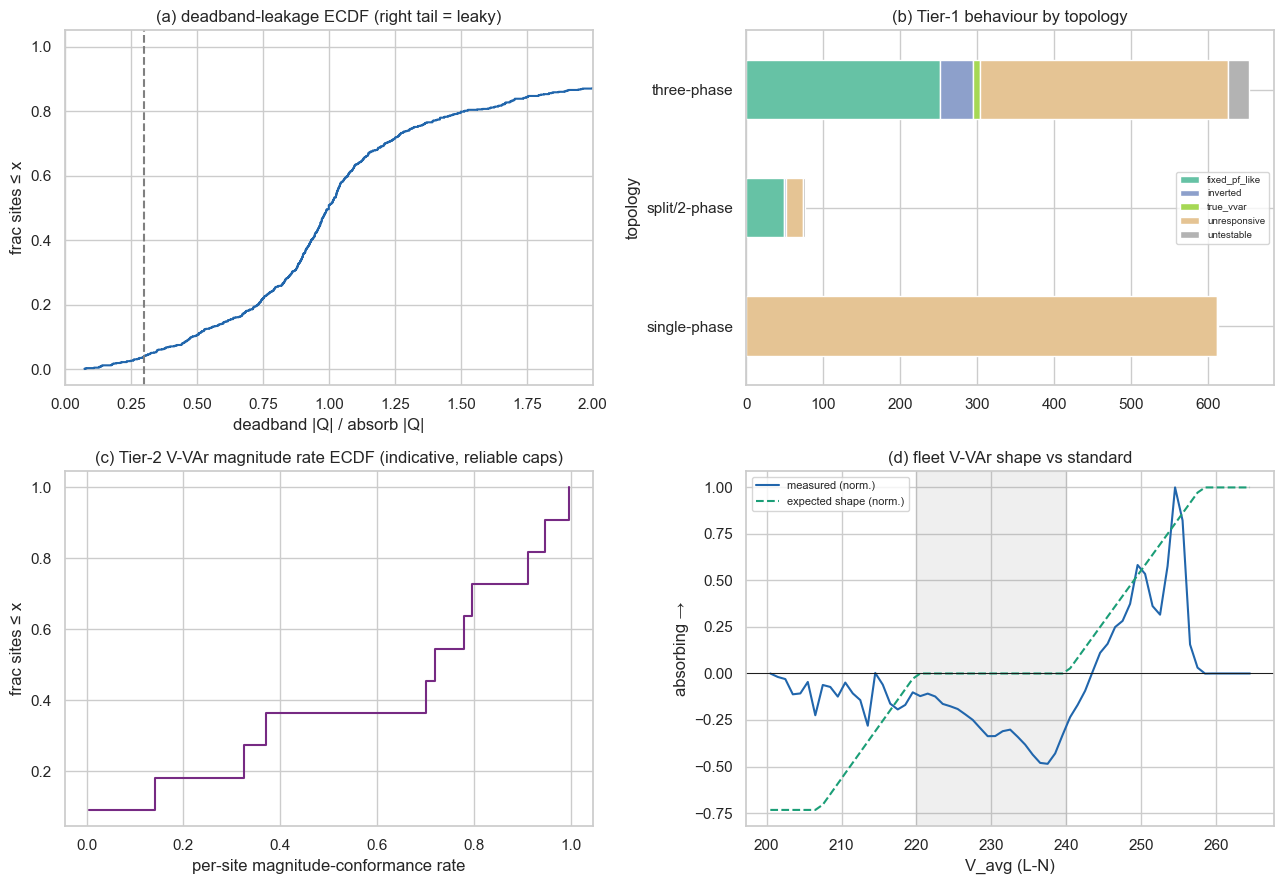

worst Tier-1 offenders (deadband leakage):


,topology,n_absorb,corr_V_absorption,deadband_ratio,vvar_behaviour
serial,,,,,
810710791,three-phase,"103,766.0000",-0.0870,32.0556,unresponsive
811193317,three-phase,"104,980.0000",-0.3625,26.2581,inverted
810671755,three-phase,"104,642.0000",-0.3487,12.5238,inverted
810744114,three-phase,"104,573.0000",-0.1365,12.4189,unresponsive
810660534,three-phase,"76,829.0000",-0.2053,8.2727,inverted
810744116,three-phase,"104,777.0000",0.0313,7.9765,unresponsive
810887305,three-phase,"103,638.0000",-0.2655,7.5806,inverted
811164409,three-phase,"97,163.0000",0.0653,7.0179,unresponsive
810414943,three-phase,"104,819.0000",-0.2230,6.5068,inverted


In [31]:
fig, ax = plt.subplots(2,2, figsize=(13,9))
# (a) deadband-leakage ECDF (Tier-1 discriminator)
dr = by_site["deadband_ratio"].dropna().sort_values().values
if len(dr):
    ax[0,0].step(dr, np.arange(1,len(dr)+1)/len(dr), where="post", color="#2166ac")
    ax[0,0].axvline(DEADBAND_CLEAN_MAX, ls="--", color="grey")
ax[0,0].set_xlim(0,min(2,np.nanmax(dr) if len(dr) else 2))
ax[0,0].set_title("(a) deadband-leakage ECDF (right tail = leaky)")
ax[0,0].set_xlabel("deadband |Q| / absorb |Q|"); ax[0,0].set_ylabel("frac sites ≤ x")
# (b) Tier-1 behaviour by topology
(by_site.groupby(["topology","vvar_behaviour"]).size().unstack(fill_value=0)
   ).plot(kind="barh", stacked=True, ax=ax[0,1], colormap="Set2")
ax[0,1].set_title("(b) Tier-1 behaviour by topology"); ax[0,1].legend(fontsize=7)
# (c) Tier-2 V-VAr magnitude rate, reliable caps only (indicative)
rel = by_site.loc[by_site["cap_reliable"]==True, "vvar_mag_rate"].dropna().sort_values().values
if len(rel):
    ax[1,0].step(rel, np.arange(1,len(rel)+1)/len(rel), where="post", color="#762a83")
ax[1,0].set_title("(c) Tier-2 V-VAr magnitude rate ECDF (indicative, reliable caps)")
ax[1,0].set_xlabel("per-site magnitude-conformance rate"); ax[1,0].set_ylabel("frac sites ≤ x")
# (d) fleet V-VAr curve vs expected shape (+ inferred-magnitude overlay)
vb = pd.cut(unit["V_avg"], bins=np.arange(200,266,1))
mabs = unit["absorption"].groupby(vb, observed=True).mean()
ctr = np.array([iv.mid for iv in mabs.index]); sc = np.nanmax(np.abs(mabs.values)) or 1
ax[1,1].plot(ctr, mabs.values/sc, color="#2166ac", label="measured (norm.)")
ax[1,1].plot(ctr, -expected_vvar_q_fraction(ctr)/0.60, color="#1b9e77", ls="--",
             label="expected shape (norm.)")
ax[1,1].axvspan(AS4777["VV2"],AS4777["VV3"], color="grey", alpha=0.12)
ax[1,1].axhline(0,color="k",lw=0.7); ax[1,1].set_title("(d) fleet V-VAr shape vs standard")
ax[1,1].set_xlabel("V_avg (L-N)"); ax[1,1].set_ylabel("absorbing →"); ax[1,1].legend(fontsize=8)
plt.tight_layout(); plt.show()

worst = by_site[by_site["n_absorb"]>=MIN_ZONE_SAMPLES].nlargest(20,"deadband_ratio")
print("worst Tier-1 offenders (deadband leakage):")
display(worst[["topology","n_absorb","corr_V_absorption","deadband_ratio","vvar_behaviour"]])

## 12. What this can and cannot claim
**Tier-1 (trust):** whether each inverter does Volt-VAr at all, in the right direction, with
a clean deadband — scale-free, no nameplate. Unit-level, with per-phase imbalance + direction
diagnostics retained.

**Tier-2 (indicative only):** magnitude vs the curve, using an **inferred** rating that is
biased low precisely by export limits and curtailment — the things the project studies.
Reported only over `cap_reliable` sites and never as a hard compliance verdict.

**Not claimable until inputs arrive:** definitive magnitude conformance (needs provider
**S_rated**); a locked sign convention (§5 uses fleet consensus → set `FLEET_SIGN_OVERRIDE`
on confirmation); Volt-Watt pass/fail at sites that never exceed 253 V (unobservable).

**Modelling assumptions, in one place:** (1) 3-phase units respond to **average** phase
voltage with **balanced/summed** power (validated per-site in §4b/§5); (2) `ActivePow` is at
the inverter terminals, gross of load — *confirm with provider*; (3) 5-min cadence
under-resolves the standard's 1 s/10 s timing (fast transients invisible); (4) Tier-2
tolerances (`*_TOL_*`) are pragmatic, not the standard's bench-test tolerances.

**Provider asks (priority):** per-`serial` S_rated → timezone → ReactPow sign convention →
confirm ActivePow is gross inverter-terminal, not net-of-load.